---
title: "Inversion strategies"
short_title: "04 · Inversion strategies"
subtitle: "Bisection vs. Newton for monotone CDFs, the safeguarded hybrid, differentiating the inverse, and vectorising it"
description: >
  Every mixture/spline marginal inverse is a monotone root-find F(x)=u. We
  compare bisection (robust, linear) and Newton (fast, fragile), build the
  safeguarded hybrid, differentiate the inverse four ways (unroll-bisection,
  unroll-Newton, one-step, adjoint) — showing the gradient depends on the
  solver — and vectorise the solve across a batch with jax.vmap.
---

(sec-nb-mt-04)=
# 04 — Inversion strategies

Notebooks [01](01_kde_mixture_cdf.ipynb)–[03](03_learnable_mixture_cdf.ipynb)
all reduced "invert the marginal" to the same problem: solve the monotone
equation $F(x) = u$ for $x$. This closing notebook of Part 1 is about *how* to
solve it well — the trade-off between **bisection** and **Newton**, the
**safeguarded hybrid** that production solvers use, and how to run the solve on
a whole **batch** at once.

**What you will see**

- **Bisection**: bracketing, derivative-free, *linearly* convergent (one bit per
  step → ~50 steps for float64), and bullet-proof for monotone $F$.
- **Newton**: uses $F'$ (the density), *quadratically* convergent (~5 steps),
  but can overshoot or **diverge** in flat tails.
- The **safeguarded Newton** hybrid — Newton when it stays in the bracket, else
  bisect — fast *and* robust.
- **Differentiating** the inverse four ways (unroll-bisection, unroll-Newton,
  one-step, adjoint) — the gradient depends on the solver, and `gauss_flows`'
  unrolled bisection returns *zero*.
- **Vectorising** the root-find across a batch with `jax.vmap`.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import time

import gauss_flows as gf
import jax
import jax.numpy as jnp
import jax.scipy.stats as jstats
import matplotlib.pyplot as plt
import numpy as np
import optimistix as optx

from _style import style_ax

jax.config.update("jax_enable_x64", True)
rng = np.random.default_rng(14)

# A 3-component mixture CDF F and its density F' (= forward derivative).
w = jnp.array([0.4, 0.35, 0.25])
mu = jnp.array([-1.5, 0.3, 2.0])
sd = jnp.array([0.4, 0.6, 0.5])


def F(x):
    return jnp.sum(w * jstats.norm.cdf(x, mu, sd))


def Fp(x):  # F'(x): the mixture density, Newton's slope
    return jnp.sum(w * jstats.norm.pdf(x, mu, sd))

## 1. Bisection vs. Newton

Both solve $F(x) = u$ for a monotone $F$, but they trade robustness against speed.

- **Bisection** keeps a bracket $[\text{lo}, \text{hi}]$ straddling the root and
  halves it each step. The error falls like $2^{-n}$ — **linear** convergence —
  so reaching float64 takes ~50 steps. It needs no derivative and *cannot* fail
  for a monotone $F$.
- **Newton** iterates $x_{n+1} = x_n - (F(x_n) - u)/F'(x_n)$. Near the root the
  error roughly **squares** each step — **quadratic** convergence, ~5 steps — but
  it needs $F'$ and, with no bracket, can overshoot into a flat tail where
  $F'\approx 0$ and diverge. We record the per-iteration error of each.

In [2]:
def bisection(u, n_iter=55):
    lo, hi, errs = -12.0, 12.0, []
    for _ in range(n_iter):
        mid = 0.5 * (lo + hi)
        errs.append(abs(float(F(mid) - u)))
        if F(mid) < u:
            lo = mid
        else:
            hi = mid
    return np.array(errs)


def newton(u, x0=0.0, n_iter=12):
    x, errs = x0, []
    for _ in range(n_iter):
        errs.append(abs(float(F(x) - u)))
        x = x - (F(x) - u) / Fp(x)
    return np.array(errs)


u = 0.7
err_bis, err_newt = bisection(u), newton(u)
print(f"bisection: {len(err_bis)} steps to {err_bis[-1]:.1e}  (linear)")
print(f"newton:    reaches {err_newt[5]:.1e} in 5 steps        (quadratic)")

# Newton's fragility: from a far-tail start aiming at an extreme quantile.
err_newt_bad = newton(0.999, x0=-8.0, n_iter=8)
print(f"newton from a bad tail start: errors = "
      f"{[f'{e:.0e}' for e in err_newt_bad[:6]]}  -> diverges (nan)")

bisection: 55 steps to 1.1e-16  (linear)
newton:    reaches 1.1e-16 in 5 steps        (quadratic)
newton from a bad tail start: errors = ['1e+00', '1e-03', '1e+00', 'nan', 'nan', 'nan']  -> diverges (nan)


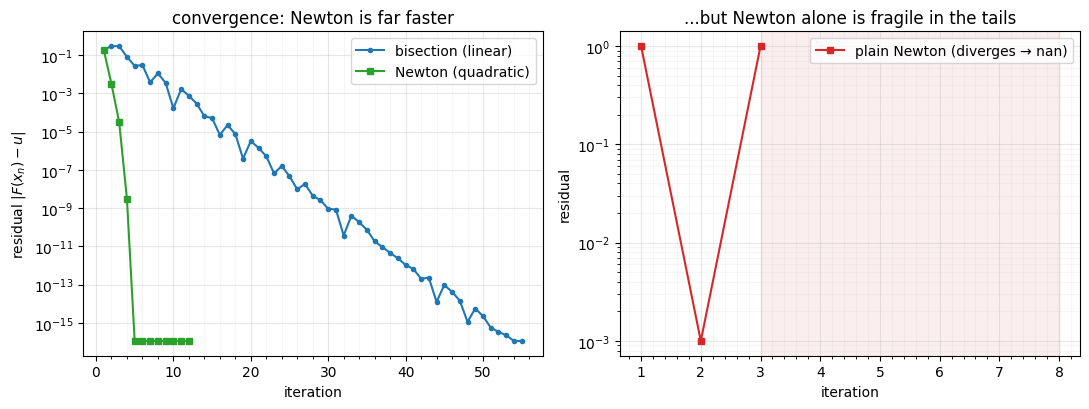

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].semilogy(range(1, len(err_bis) + 1), np.maximum(err_bis, 1e-17), "-o",
                 ms=3, color="tab:blue", label="bisection (linear)")
axes[0].semilogy(range(1, len(err_newt) + 1), np.maximum(err_newt, 1e-17), "-s",
                 ms=4, color="tab:green", label="Newton (quadratic)")
axes[0].set(title="convergence: Newton is far faster",
            xlabel="iteration", ylabel=r"residual $|F(x_n) - u|$")
axes[0].legend(); style_ax(axes[0])

steps_bad = np.arange(1, len(err_newt_bad) + 1)
finite = np.isfinite(err_newt_bad)
axes[1].semilogy(steps_bad[finite], np.maximum(err_newt_bad[finite], 1e-17), "-s",
                 ms=5, color="tab:red", label="plain Newton (diverges → nan)")
axes[1].axvspan(steps_bad[finite][-1], len(err_newt_bad), color="tab:red", alpha=0.08)
axes[1].set(title="...but Newton alone is fragile in the tails",
            xlabel="iteration", ylabel="residual")
axes[1].legend(); style_ax(axes[1])
fig.tight_layout()

Left: Newton (green) reaches machine precision in ~5 steps where bisection
(blue) needs ~50 — quadratic vs. linear. Right: starting Newton far out in the
tail, the tiny $F'$ throws the iterate even further out and it blows up to
`nan`. Bisection would simply have kept halving. We want Newton's speed without
its fragility.

## 2. The safeguarded hybrid

The standard fix (Brent-style {cite}`brent1973algorithms`) keeps a **bracket** like bisection but *tries* a
Newton step each iteration, accepting it only if it lands **inside** the
bracket; otherwise it falls back to the bisection midpoint. This keeps the
guaranteed convergence of bisection and the speed of Newton near the root — and
it is essentially what robust library solvers do.

safeguarded Newton on the hard tail target: 1.1e-16, all finite = True


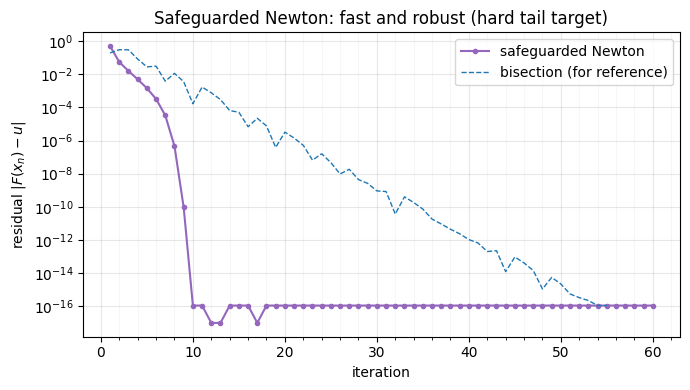

In [4]:
def safeguarded_newton(u, n_iter=60):
    lo, hi, x, errs = -12.0, 12.0, 0.0, []
    for _ in range(n_iter):
        errs.append(abs(float(F(x) - u)))
        lo, hi = (x, hi) if F(x) < u else (lo, x)   # tighten bracket
        step = x - (F(x) - u) / Fp(x)               # Newton proposal
        x = step if lo < step < hi else 0.5 * (lo + hi)  # accept or bisect
    return np.array(errs)


err_safe = safeguarded_newton(0.999)  # the same hard target that broke Newton
print(f"safeguarded Newton on the hard tail target: {err_safe[-1]:.1e}, "
      f"all finite = {bool(np.all(np.isfinite(err_safe)))}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(range(1, len(err_safe) + 1), np.maximum(err_safe, 1e-17), "-o", ms=3,
            color="tab:purple", label="safeguarded Newton")
ax.semilogy(range(1, len(err_bis) + 1), np.maximum(err_bis, 1e-17), "--", lw=1,
            color="tab:blue", label="bisection (for reference)")
ax.set(title="Safeguarded Newton: fast and robust (hard tail target)",
       xlabel="iteration", ylabel=r"residual $|F(x_n) - u|$")
ax.legend(); style_ax(ax)
fig.tight_layout()

On the very target that sent plain Newton to `nan`, the safeguarded version
stays finite and converges quickly — the bracket catches every bad Newton step.
`optimistix` {cite}`kidger2021ndes` ships both primitives (`optx.Bisection`,
`optx.Newton`) and composes them; `gauss_flows` uses the robust bracketing
bisection by default
(we saw its internals in [notebook 03](03_learnable_mixture_cdf.ipynb)).

## 3. Differentiating the inverse

To train a flow through its *sampling* path we need to differentiate the
inverse — $\partial x_\star/\partial u$ and $\partial x_\star/\partial\theta$.
Crucially, **whether you get the right gradient depends on the solver**. There
are four options:

| strategy | idea | pros | cons |
|---|---|---|---|
| unroll **bisection** | backprop the bracketing loop | trivial | **wrong (zero)** — the `where(F<u)` comparisons are piecewise constant |
| unroll **Newton** | backprop the smooth update | correct gradient; trivial | memory $O(\#\text{iters})$ — stores every iterate |
| **one-step** | detach the root, add one Newton step | exact; $O(1)$ memory; ~3 lines | needs $F'$ at $x_\star$ |
| **adjoint** (implicit-fn thm) | differentiate $F(x_\star)=u$ directly | exact; $O(1)$; automatic in `optimistix`; scales to vector roots | a linear solve |

The last three all compute the **implicit-function** gradient
{cite}`blondel2022implicit`, which depends only on the solution:

$$
\frac{\partial x_\star}{\partial u} = \frac{1}{F'(x_\star)},
\qquad
\frac{\partial x_\star}{\partial \theta}
  = -\frac{\partial_\theta F(x_\star)}{F'(x_\star)} .
$$

Unrolling instead differentiates the *path* to $x_\star$ — which is why it is
correct for smooth Newton but useless for comparison-based bisection.

In [5]:
_isolver = optx.Bisection(rtol=1e-12, atol=1e-14)


def _solve(u):  # the converged root (used by one-step and adjoint)
    return optx.root_find(lambda x, a: F(x) - a, _isolver, 0.0, args=u,
                          options=dict(lower=-12.0, upper=12.0), max_steps=200,
                          throw=False).value


def inv_unroll_bisect(u, n=60):          # (1) unroll bisection -> zero grad
    lo, hi = -12.0, 12.0
    for _ in range(n):
        mid = 0.5 * (lo + hi)
        below = F(mid) < u
        lo = jnp.where(below, mid, lo)
        hi = jnp.where(below, hi, mid)
    return 0.5 * (lo + hi)


def inv_unroll_newton(u, n=30):          # (2) unroll Newton -> correct, O(n) memory
    x = 0.0
    for _ in range(n):
        x = x - (F(x) - u) / Fp(x)
    return x


def inv_onestep(u):                      # (3) detach + one Newton step -> exact, O(1)
    x_star = jax.lax.stop_gradient(_solve(u))
    return x_star - (F(x_star) - u) / Fp(x_star)


def inv_adjoint(u):                      # (4) optimistix ImplicitAdjoint -> exact, O(1)
    return _solve(u)


uu = jnp.linspace(0.03, 0.97, 40)
g_analytic = jax.vmap(lambda u: 1.0 / Fp(_solve(u)))(uu)
g_unroll_b = jax.vmap(jax.grad(inv_unroll_bisect))(uu)
g_unroll_n = jax.vmap(jax.grad(inv_unroll_newton))(uu)
g_onestep = jax.vmap(jax.grad(inv_onestep))(uu)
g_adjoint = jax.vmap(jax.grad(inv_adjoint))(uu)

amax = lambda g: float(jnp.max(jnp.abs(g - g_analytic)))
print(f"max |unroll-Newton - analytic| = {amax(g_unroll_n):.2e}   (correct)")
print(f"max |one-step     - analytic| = {amax(g_onestep):.2e}   (correct)")
print(f"max |adjoint      - analytic| = {amax(g_adjoint):.2e}   (correct)")
print(f"unroll-bisection grad range   = [{float(g_unroll_b.min()):.0e}, "
      f"{float(g_unroll_b.max()):.0e}]   <- zero (wrong)")

max |unroll-Newton - analytic| = 6.00e-12   (correct)
max |one-step     - analytic| = 0.00e+00   (correct)
max |adjoint      - analytic| = 3.55e-15   (correct)
unroll-bisection grad range   = [0e+00, 0e+00]   <- zero (wrong)


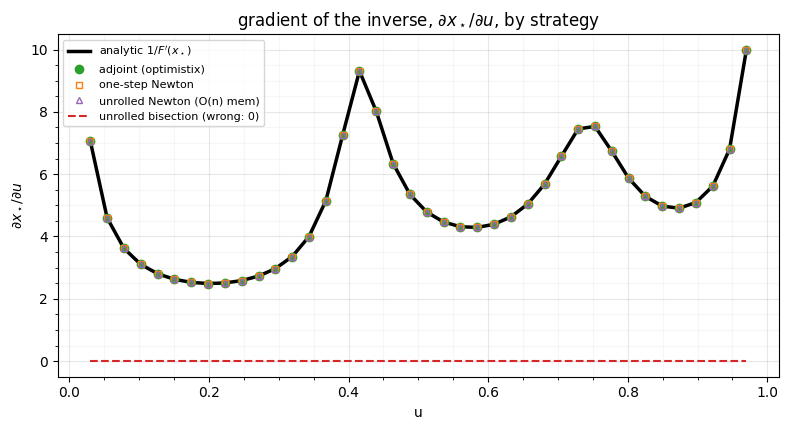

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(uu, g_analytic, "-", color="k", lw=2.5, label=r"analytic $1/F'(x_\star)$")
ax.plot(uu, g_adjoint, "o", color="tab:green", ms=6, label="adjoint (optimistix)")
ax.plot(uu, g_onestep, "s", color="tab:orange", ms=5, mfc="none", label="one-step Newton")
ax.plot(uu, g_unroll_n, "^", color="tab:purple", ms=5, mfc="none",
        label="unrolled Newton (O(n) mem)")
ax.plot(uu, g_unroll_b, "--", color="tab:red", lw=1.5, label="unrolled bisection (wrong: 0)")
ax.set(title=r"gradient of the inverse, $\partial x_\star/\partial u$, by strategy",
       xlabel="u", ylabel=r"$\partial x_\star / \partial u$")
ax.legend(fontsize=8); style_ax(ax)
fig.tight_layout()

Three of the four land on the analytic curve; only **unrolled bisection** is
flat at zero, because its iterates depend on the inputs solely through `<`
comparisons. Unrolled *Newton* is correct — its update is smooth — but pays
$O(\#\text{iters})$ memory, so the $O(1)$ **one-step** and **adjoint** methods
win for deep flows. This trap is live: `gauss_flows`' `MixtureGaussianCDF.inverse`
is an unrolled bisection, so differentiating it returns zero
([gauss_flows#111](https://github.com/jejjohnson/gauss_flows/issues/111)):

In [7]:
b = gf.MixtureGaussianCDF.from_data(jnp.asarray(rng.normal(0, 1.5, (2000, 1))), 6)
y = jnp.array([0.7])
g_lib = float(jax.grad(lambda yy: b.inverse(yy).sum())(y)[0])
g_fwd = float(jax.grad(lambda xx: b.transform(xx).sum())(b.inverse(y))[0])
print(f"grad through gauss_flows .inverse = {g_lib:.4f}   <- 0 (unrolled bisection)")
print(f"correct implicit value 1/F'(x*)   = {1.0 / g_fwd:.4f}")
print("=> fine for density/log_prob (forward); wrap with optimistix or one-step "
      "to train through sampling")

grad through gauss_flows .inverse = 0.0000   <- 0 (unrolled bisection)
correct implicit value 1/F'(x*)   = 1.1619
=> fine for density/log_prob (forward); wrap with optimistix or one-step to train through sampling


## 4. Vectorising across a batch

A flow inverts a *whole array* of values at once (every sample, every
dimension). We never write a Python loop over elements — we write the scalar
solve once and `jax.vmap` it, which fuses the batch into a single compiled
kernel. (Bisection vectorises especially naturally: the bracket updates are
`jnp.where` over arrays — exactly what `gauss_flows`' `bisection_inverse` does.)

In [8]:
solver = optx.Bisection(rtol=1e-10, atol=1e-12)


def solve_one(u):
    return optx.root_find(lambda x, a: F(x) - a, solver, 0.0, args=u,
                          options=dict(lower=-12.0, upper=12.0), max_steps=200,
                          throw=False).value


batched = jax.jit(jax.vmap(solve_one))     # vectorised over the leading axis
solve_jit = jax.jit(solve_one)             # same solve, jitted but called per-element
U = jnp.asarray(rng.uniform(0.01, 0.99, 4000))
batched(U).block_until_ready()             # warmup / compile
solve_jit(U[0]).block_until_ready()

t = time.perf_counter()
for _ in range(5):
    batched(U).block_until_ready()
t_vmap = (time.perf_counter() - t) / 5

# Python loop over a subset, calling the *compiled* scalar solve per element —
# a fair contrast (dispatch-per-element vs. one fused batch, not recompilation).
sub = U[:400]
t = time.perf_counter()
for uu in sub:
    solve_jit(uu).block_until_ready()
t_loop = time.perf_counter() - t

per_vmap = t_vmap / len(U) * 1e6
per_loop = t_loop / len(sub) * 1e6
print(f"vmap : {t_vmap * 1e3:6.2f} ms for {len(U)} inversions  ({per_vmap:.2f} µs each)")
print(f"loop : {t_loop * 1e3:6.2f} ms for {len(sub)} inversions ({per_loop:.1f} µs each)")
print(f"=> vmap is ~{per_loop / per_vmap:.0f}x faster per inversion")

# correctness: F(x*) recovers u
err = float(jnp.max(jnp.abs(jax.vmap(F)(batched(U)) - U)))
print(f"batched inversion accuracy: max|F(x*) - u| = {err:.1e}")

vmap :   5.19 ms for 4000 inversions  (1.30 µs each)
loop : 119.17 ms for 400 inversions (297.9 µs each)
=> vmap is ~229x faster per inversion


batched inversion accuracy: max|F(x*) - u| = 2.6e-11


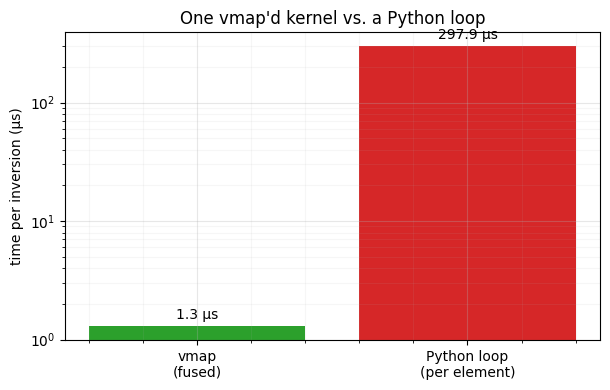

In [9]:
fig, ax = plt.subplots(figsize=(6.2, 4))
bars = ax.bar(["vmap\n(fused)", "Python loop\n(per element)"],
              [per_vmap, per_loop], color=["tab:green", "tab:red"])
ax.bar_label(bars, fmt="%.1f µs", padding=3)
ax.set(ylabel="time per inversion (µs)", yscale="log",
       title="One vmap'd kernel vs. a Python loop")
style_ax(ax)
fig.tight_layout()

Same solver, but `vmap` amortises tracing and dispatch across the whole batch —
orders of magnitude faster per element than looping, and it composes with
`jax.jit`/`grad`. For a $d$-dimensional marginal layer you simply `vmap` over the
leading (batch) axes and apply the scalar solve per coordinate.

## Recap

*Solving* $F(x)=u$:

| method | convergence | needs $F'$? | robust? | use |
|---|---|---|---|---|
| bisection | linear ($2^{-n}$) | no | always (monotone) | default; `gauss_flows` inverse |
| Newton | quadratic | yes | no (tails) | when bracketed & well-scaled |
| safeguarded Newton | quadratic + safe | yes | yes | best of both (Brent-style) |

*Differentiating* the inverse, and *scaling* it:

| technique | gradient | memory | note |
|---|---|---|---|
| unroll bisection | **wrong (0)** | $O(n)$ | comparisons kill the gradient |
| unroll Newton | correct | $O(n)$ | smooth update; memory-heavy |
| one-step | correct | $O(1)$ | detach + 1 Newton step |
| adjoint | correct | $O(1)$ | `optimistix` `ImplicitAdjoint`; automatic |
| `jax.vmap` | — | — | batch the scalar solve into one kernel |

**Next up — end of Part 1.** We can now build, fit, train, and invert a single
1D marginal transform every way that matters. **Part 2** stacks them with
**rotations** (PCA, Householder, random) so that marginal Gaussianization can
attack *multivariate* dependence — the second half of the RBIG loop from
[Part 0 notebook 04](../00_foundations/04_density_destructors.ipynb).